In [77]:
import numpy as np

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn import datasets

%matplotlib inline
plt.rcParams["figure.figsize"] = [12, 8]

np.random.seed(42)

In [78]:
import warnings
warnings.filterwarnings("ignore")

# Логистическая регрессия

Проиллюстрируем работу логистической регрессии на игрушечном примере. Сгенерируем двумерный набор точек на плоскости с помощью функции `make_classification`.

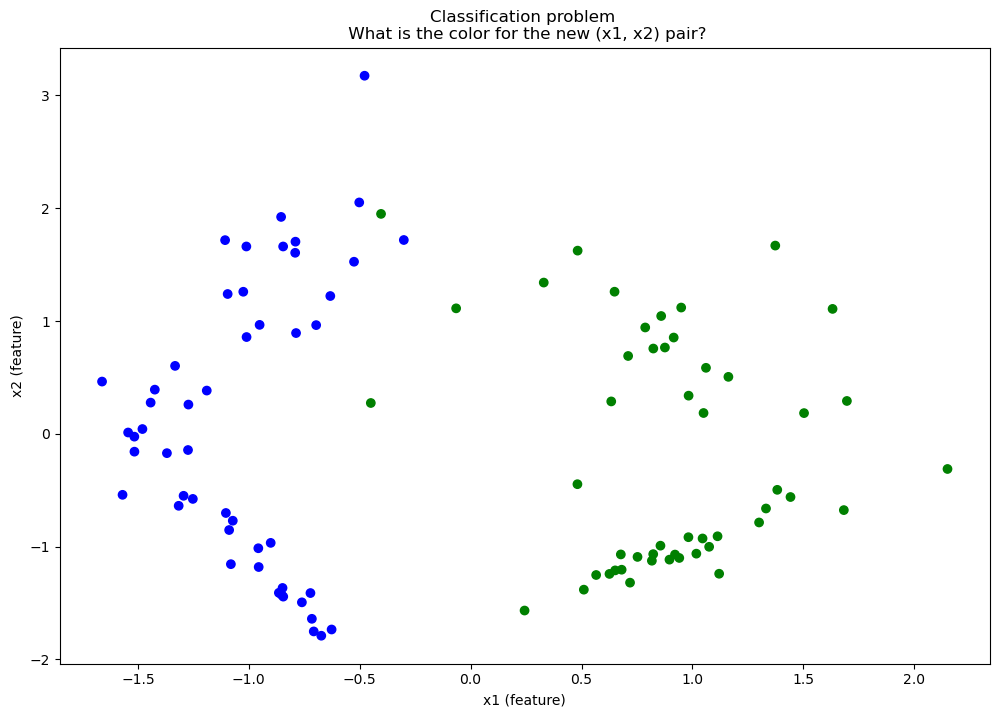

In [79]:
X, y = datasets.make_classification(n_samples=100, n_features=2, n_informative=2, n_redundant=0, n_repeated=0, random_state=1)

colors = ['green' if y_i else 'blue' for y_i in y]
plt.scatter(X[:, 0], X[:, 1], c=colors)
plt.title("Classification problem \n What is the color for the new (x1, x2) pair?")
plt.xlabel("x1 (feature)")
plt.ylabel("x2 (feature)")
plt.show()

# Линейный классификатор

Построим случайную прямую. Насколько хорошо она описывает данные?

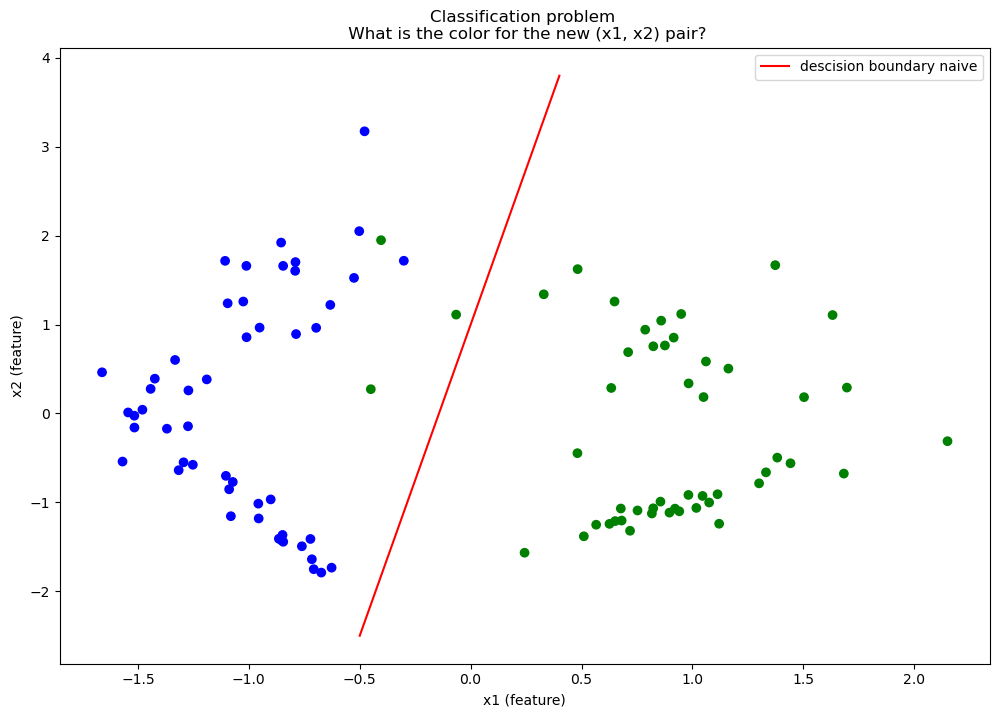

In [81]:
x_naive = np.arange(-0.5, 0.5, 0.1)
y_naive = 7 * x_naive + 1
# y_naive = 2 * x_naive + 1

plt.scatter(X[:, 0], X[:, 1], c=colors)
plt.title("Classification problem \n What is the color for the new (x1, x2) pair?")
plt.xlabel("x1 (feature)")
plt.ylabel("x2 (feature)")
plt.plot(x_naive, y_naive, c='red', label='descision boundary naive')
plt.legend();

## Как принимается решение

Простой вариант узнать, с какой стороны от гиперплоскости находится точка, посмотрев на ее знак относительно этой прямой.

$$\hat{y} = sign(x\theta)$$

In [82]:
w = np.array([7, -1, 1]) # Ax + By + C = 0

# Замечание: расстояние от точки (x0, y0) до прямой Ax + By + C это abs(Ax0 + By0 + C) / sqrt(A^2 + B^2)

def predict(x, w):
    return np.sign(x.dot(w))

x_pred = np.hstack([np.random.rand(20, 2) * 4 - 2, np.ones(20).reshape(-1, 1)])
y_pred = predict(x_pred, w)

print(x_pred.shape)
print(y_pred.shape)

(20, 3)
(20,)


In [83]:
x_pred.dot(w)

array([ -4.3157339 ,   7.10119643,  -7.25545615, -12.83836344,
         2.99893002, -14.30327357,  11.4590375 ,  -6.64251896,
        -4.58024292,  -0.07045604,   5.57390561,  -4.28539721,
        -1.37074429,  -7.46607185,   5.40180628,   5.32915936,
       -12.97409755,  12.80410753,  -2.86150292,   6.39791477])

In [84]:
y_pred

array([-1.,  1., -1., -1.,  1., -1.,  1., -1., -1., -1.,  1., -1., -1.,
       -1.,  1.,  1., -1.,  1., -1.,  1.])

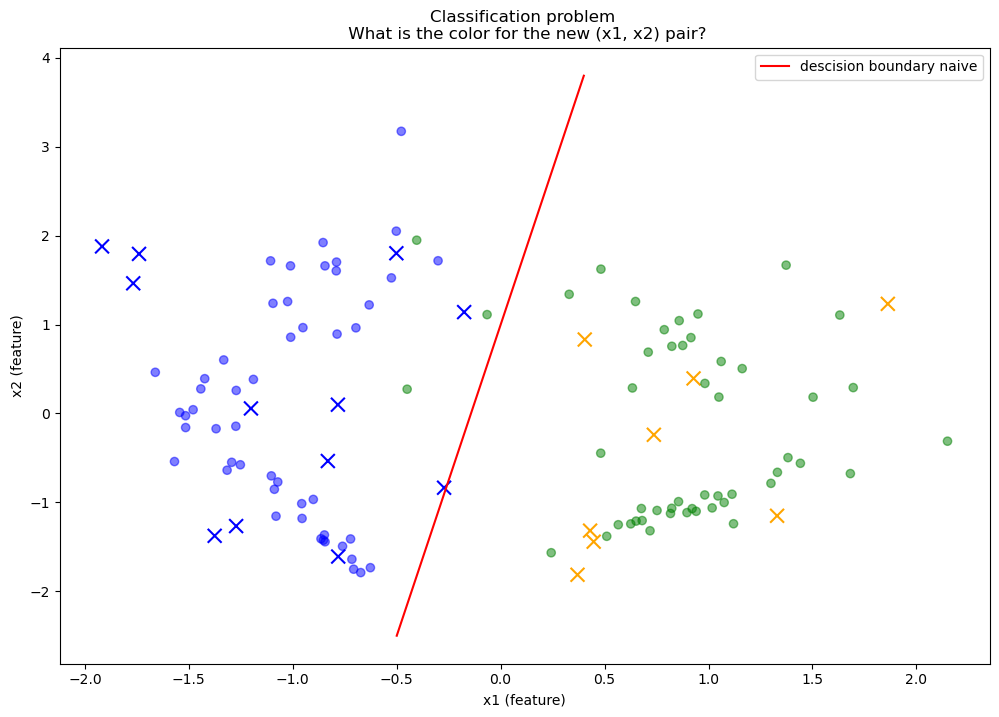

In [85]:
x_naive = np.arange(-0.5, 0.5, 0.1)
# naive boundary
y_naive = 7 * x_naive + 1
# y_naive = 2 * x_naive + 1

plt.scatter(x_pred[:, 0], x_pred[:, 1], c=['orange' if y_i > 0 else 'blue' for y_i in y_pred], marker='x', s=100)
plt.title("Classification problem \n What is the color for the new (x1, x2) pair?")
plt.xlabel("x1 (feature)")
plt.ylabel("x2 (feature)")
plt.scatter(X[:, 0], X[:, 1], c=colors, alpha=0.5)
plt.plot(x_naive, y_naive, c='red', label='descision boundary naive')
plt.legend();

## Логистическая регрессия в sklearn

к счатью в реальной жизни нам не придется писать код для модели логистической регрессии, ведь в `sklearn` этот алгоритм уже реализован за нас в виде класса `LogisticRegression`.

рассмотрим пример его использования.

In [31]:
from sklearn.linear_model import LogisticRegression

In [87]:
# LogisticRegression?

In [34]:

log_reg = LogisticRegression()
log_reg.fit(X, y)

x0, x1 = np.meshgrid(
        np.linspace(-2, 2, 500).reshape(-1, 1),
        np.linspace(-3, 3, 200).reshape(-1, 1),
    )
X_new = np.c_[x0.ravel(), x1.ravel()]

y_proba = log_reg.predict_proba(X_new)



In [90]:
y_proba[:10]

array([[0.9981735 , 0.0018265 ],
       [0.99812326, 0.00187674],
       [0.99807165, 0.00192835],
       [0.99801861, 0.00198139],
       [0.99796412, 0.00203588],
       [0.99790814, 0.00209186],
       [0.99785062, 0.00214938],
       [0.99779152, 0.00220848],
       [0.9977308 , 0.0022692 ],
       [0.99766842, 0.00233158]])

In [41]:
y_pred = log_reg.predict(X_new)
y_pred[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

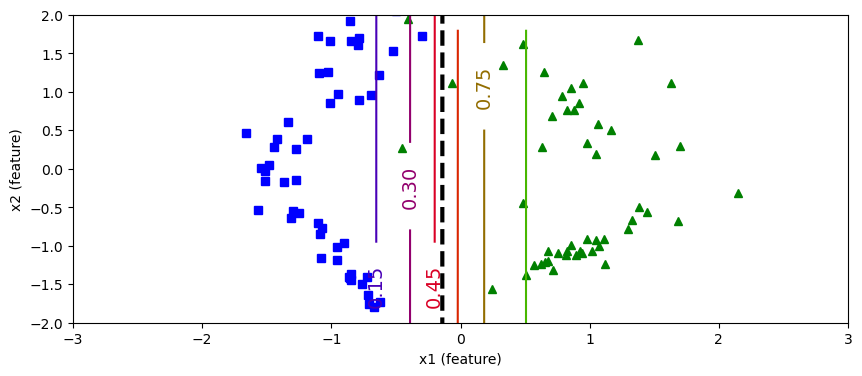

In [44]:

plt.figure(figsize=(10, 4))
plt.plot(X[y==0, 0], X[y==0, 1], "bs")
plt.plot(X[y==1, 0], X[y==1, 1], "g^")
zz = y_proba[:, 1].reshape(x0.shape)
contour = plt.contour(x0, x1, zz, cmap=plt.cm.brg)
left_right = np.array([-3, 3])
boundary = -(log_reg.coef_[0][0] * left_right + log_reg.intercept_[0]) / log_reg.coef_[0][1]
plt.clabel(contour, inline=1, fontsize=14)
plt.plot(left_right, boundary, "k--", linewidth=3)
plt.xlabel("x1 (feature)")
plt.ylabel("x2 (feature)")
plt.axis([-3, 3, -2, 2])
plt.show()

# Пример на реальных даных

Сегодня посмотрим на задачу с [Kaggle](https://www.kaggle.com/uciml/biomechanical-features-of-orthopedic-patients#_=_).



Цель задачи: предсказать наличие ортопедических проблем по измерениям костей таза и нижнего позвоночника пациентов.



Сначала загрузим данные с помощью метода `wget`, который позволяет скачивать данные по ссылке на скачивание.

In [45]:
# !wget -O column_2C_weka.csv https://drive.usercontent.google.com/download?id=1JGRlocS9FlTpcqRsPVVHJ2fc3Q6vRJbe&export=download&authuser=0&confirm=t&uuid=2c2f5ee8-78f3-4040-b7a5-a7ba35ecb432&at=AO7h07f5JXMog1-8zXdjkYsi71Aq:1727170889921

Теперь быстро пройдемся по основным этапам работы с данными.

Загрузка - Статистики и Визуализация - Предобработка - Моделирование

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [91]:
def quality_report(prediction, actual):
    print("Accuracy: {:.3f}\nPrecision: {:.3f}\nRecall: {:.3f}\nf1_score: {:.3f}".format(
        accuracy_score(prediction, actual),
        precision_score(prediction, actual),
        recall_score(prediction, actual),
        f1_score(prediction, actual)
    ))

In [92]:
data = pd.read_csv('column_2C_weka.csv')

# перекодируем целевую
data['class'] = data['class'].apply(lambda x: 1 if x=='Abnormal' else 0)

In [93]:
data.head()

,pelvic_incidence,pelvic_tilt numeric,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis,class
0,63.027817,22.552586,39.609117,40.475232,98.672917,-0.254400,1
1,39.056951,10.060991,25.015378,28.995960,114.405425,4.564259,1
2,68.832021,22.218482,50.092194,46.613539,105.985135,-3.530317,1
3,69.297008,24.652878,44.311238,44.644130,101.868495,11.211523,1
4,49.712859,9.652075,28.317406,40.060784,108.168725,7.918501,1


Разделим данные на train и test и нормируем.

In [68]:
# train-test split
X_data = data.drop(['class'], axis=1)
y_data = data['class']
X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_data, test_size=0.2, random_state=2, stratify=y_data
)

# стандартизируем
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [70]:
X_train_scaled[:10]

array([[ 5.55125750e-01, -4.15747975e-01,  4.62175334e-01,
         1.03716973e+00, -1.17677580e+00, -3.31300572e-02],
       [-7.12363849e-01, -1.27067146e-01, -8.54698515e-01,
        -8.29179978e-01, -1.73780560e+00,  4.02414390e-02],
       [ 8.93745988e-01,  2.37203493e+00,  2.16101936e+00,
        -6.40372587e-01,  1.07554663e+00,  1.94620942e+00],
       [-8.68035204e-01, -4.54962721e-01, -1.17402095e+00,
        -7.82404925e-01,  4.39368159e-04, -8.31493688e-01],
       [-3.87081860e-01, -8.23517656e-01, -4.96165383e-01,
         1.22532295e-01,  4.83341061e-01, -4.50641505e-02],
       [ 5.18334154e-01,  1.53225769e-01, -2.10270087e-01,
         5.57173467e-01, -1.61672001e+00,  6.37227130e-01],
       [ 3.16139173e+00,  1.93930431e+00,  1.28817128e+00,
         2.63507353e+00, -9.99096100e-01,  1.42261131e+00],
       [ 5.46602755e-01, -7.22292155e-01,  1.26540717e+00,
         1.25894207e+00,  9.49712088e-02,  1.53297164e-01],
       [ 6.66436961e-01, -1.26741269e-01,  3.917

### Logistic Regression

Обучим логистическую регрессию из библиотеки `sklearn`.

In [72]:
from sklearn.linear_model import LogisticRegression

In [94]:
log_reg = LogisticRegression(penalty=None)

log_reg.fit(X_train_scaled, y_train)
print("Train quality:")
quality_report(log_reg.predict(X_train_scaled), y_train)

print("\nTest quality:")
quality_report(log_reg.predict(X_test_scaled), y_test)


Train quality:
Accuracy: 0.855
Precision: 0.887
Recall: 0.898
f1_score: 0.892

Test quality:
Accuracy: 0.823
Precision: 0.857
Recall: 0.878
f1_score: 0.867


In [95]:
log_reg = LogisticRegression()

log_reg.fit(X_train_scaled, y_train)
print("Train quality:")
quality_report(log_reg.predict(X_train_scaled), y_train)
print("\nTest quality:")
quality_report(log_reg.predict(X_test_scaled), y_test)

Train quality:
Accuracy: 0.863
Precision: 0.881
Recall: 0.914
f1_score: 0.897

Test quality:
Accuracy: 0.855
Precision: 0.881
Recall: 0.902
f1_score: 0.892


Для модели логистической регрессии мы можем оценить важность признаков, которая будет соотвествовать коэффициенту при этом признаке в обученной модели. ажность признаков

In [54]:
log_reg.coef_

array([[-0.12468026,  0.66257818, -0.11993622, -0.66530632, -0.97545681,
         3.8536607 ]])

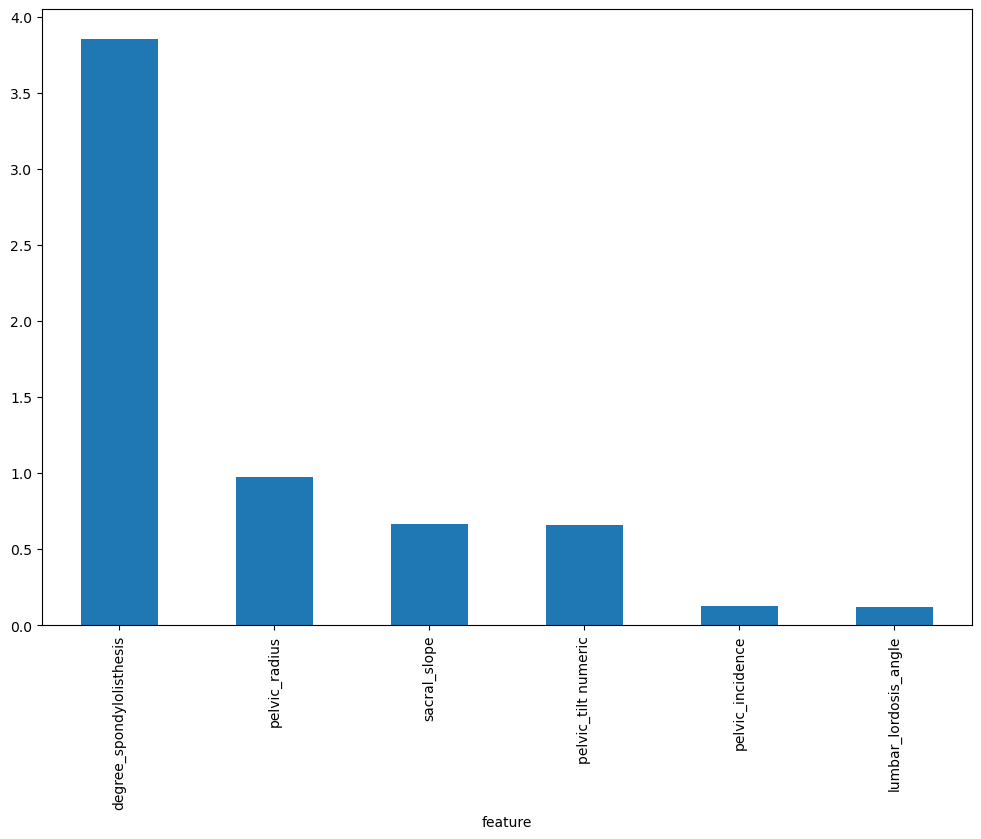

In [55]:
featureImportance = pd.DataFrame({"feature": data.drop('class',axis=1).columns,
                                  "importance": abs(log_reg.coef_[0])})

featureImportance.set_index('feature', inplace=True)
featureImportance.sort_values(["importance"], ascending=False, inplace=True)
featureImportance["importance"].plot.bar();

### Вероятности

In [56]:
log_reg.predict_proba(X_test_scaled)[:10]

array([[0.33943181, 0.66056819],
       [0.98484426, 0.01515574],
       [0.49875732, 0.50124268],
       [0.53280136, 0.46719864],
       [0.29776816, 0.70223184],
       [0.15362282, 0.84637718],
       [0.05916986, 0.94083014],
       [0.05250968, 0.94749032],
       [0.01426421, 0.98573579],
       [0.32208743, 0.67791257]])

In [57]:
log_reg.predict(X_test_scaled)[:10]

array([1, 0, 1, 0, 1, 1, 1, 1, 1, 1])

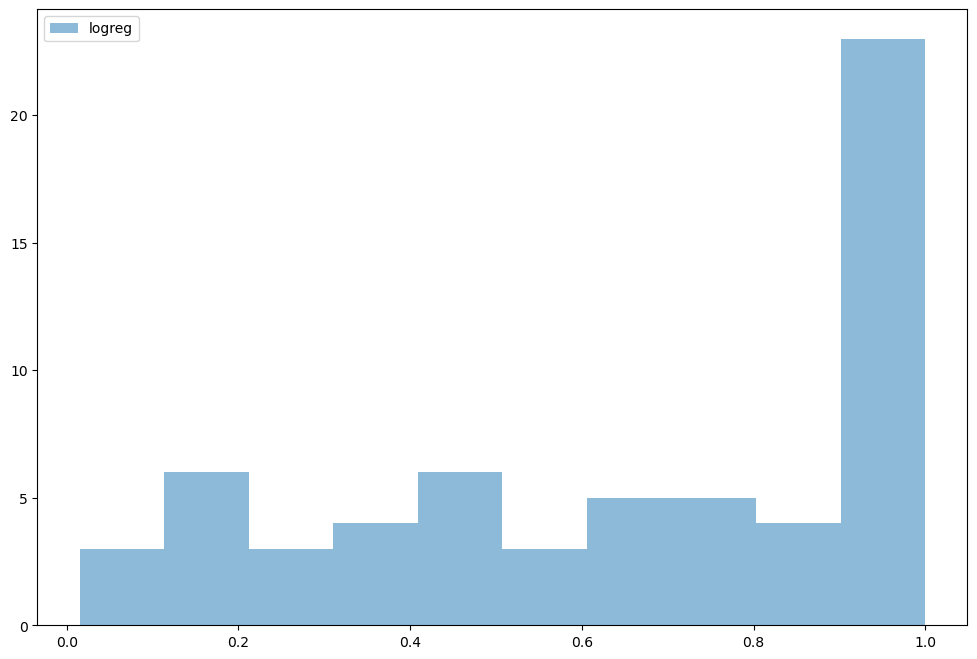

In [96]:
plt.hist(log_reg.predict_proba(X_test_scaled)[:, 1], alpha=0.5, label = 'logreg');
plt.legend()
plt.show()


## ROC_AUC

In [74]:
from sklearn.metrics import roc_auc_score, roc_curve, auc
print('ROC-AUC ', round(roc_auc_score(y_test, log_reg.predict_proba(X_test_scaled)[:,1]),3))

ROC-AUC  0.948


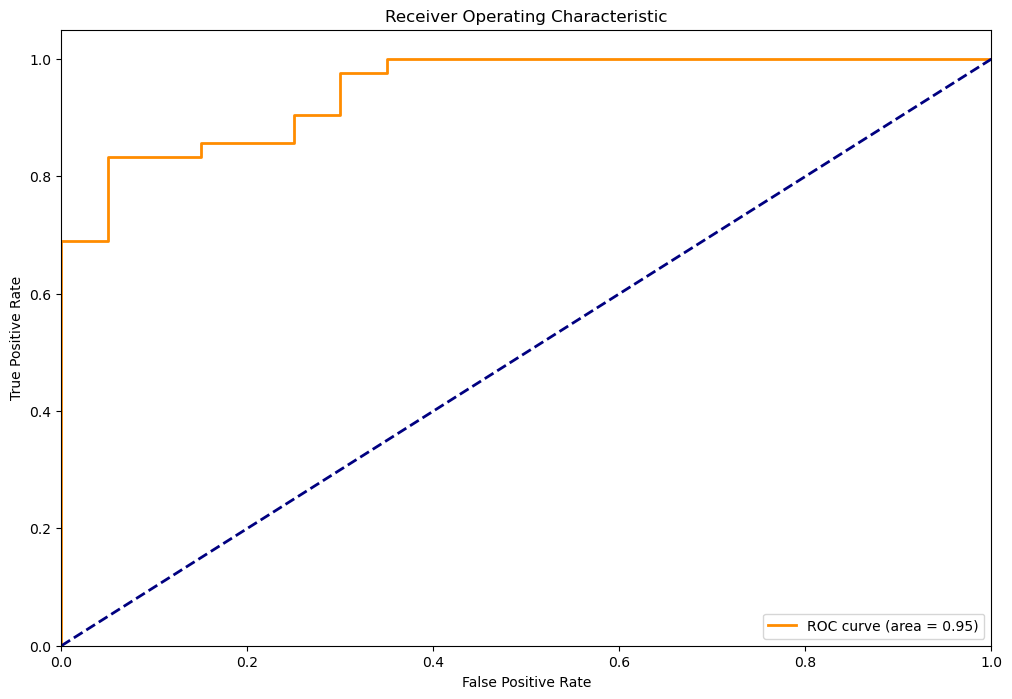

In [75]:
# Вычисляем ROC-кривую
fpr, tpr, thresholds = roc_curve(y_test, log_reg.predict_proba(X_test_scaled)[:,1])

# Вычисляем AUC
roc_auc = auc(fpr, tpr)

# Строим график
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

## Регуляризация


* Добавить дополнительное ограничение на норму вектора весов $R(\omega)$:
$$
LogLoss+\lambda R(\omega)\to\min_{\beta}
$$
* $\lambda>0$ - гиперпараметр.
* $R(\omega)$ штраф за сложность модели.

$$
\begin{array}{ll}
R(\omega)=||\omega||_{1} &  \text{(L1) Lasso regression}\\
R(\omega)=||\omega||_{2}^{2} & \text{(L2) Ridge regression}
\end{array}
$$


### L2 Ridge

In [97]:
from sklearn.model_selection import GridSearchCV
parameters = {'C': [0.001, 0.01, 0.1, 1]}

log_reg = LogisticRegression(penalty = 'l2')
clf = GridSearchCV(log_reg, parameters, scoring = 'roc_auc', cv = 5)
clf.fit(data.drop(['class'], axis=1), data['class'])

GridSearchCV(cv=5, estimator=LogisticRegression(),
             param_grid={'C': [0.001, 0.01, 0.1, 1]}, scoring='roc_auc')

In [98]:
pd.DataFrame(clf.cv_results_)[['param_C','mean_test_score']]

,param_C,mean_test_score
0,0.001,0.905000
1,0.010,0.909524
2,0.100,0.909762
3,1.000,0.909762


In [99]:
print('Best C:', clf.best_params_, '\t Best score: ',clf.best_score_)

Best C: {'C': 0.1} 	 Best score:  0.9097619047619048


### L1 Lasso

In [102]:
from sklearn.model_selection import GridSearchCV
parameters = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}

log_reg = LogisticRegression(solver = 'liblinear', penalty = 'l1')
clf = GridSearchCV(log_reg, parameters, scoring = 'roc_auc', cv = 5)
clf.fit(data.drop(['class'], axis=1), data['class'])

GridSearchCV(cv=5,
             estimator=LogisticRegression(penalty='l1', solver='liblinear'),
             param_grid={'C': [0.001, 0.01, 0.1, 1, 10, 100]},
             scoring='roc_auc')

In [103]:
pd.DataFrame(clf.cv_results_)[['param_C','mean_test_score']]

,param_C,mean_test_score
0,0.001,0.859048
1,0.010,0.871667
2,0.100,0.889524
3,1.000,0.892143
4,10.000,0.908571
5,100.000,0.909762


In [104]:
print('Best C:', clf.best_params_, '\t Best score: ',clf.best_score_)

Best C: {'C': 100} 	 Best score:  0.9097619047619048
